# EDA geográfico 

**Objetivo:** entender *dónde* ocurre la demanda de Ecobici.

**Datos**
- `data/processed/trips_clean.parquet` — histórico de viajes (generado con `python src/ingest.py`).
- `data/processed/stations_geo.csv` y `cdmx_cp_ecobici.geojson` — capa geográfica (`python src/geo.py`).
- `data/processed/station_status_snapshot.csv` — foto del estado en tiempo real (`python src/stations.py`).

**Funciones del proyecto que se usan:** `geo_utils.load_stations_geo`, `geo_utils.unir_geo`,
`geo_utils.plot_mapa_base` y `eda_utils.load_status_snapshot`.

> Los polígonos del mapa son **códigos postales** (SEPOMEX), no colonias. La alcaldía
> se deriva del prefijo del CP (aproximación).

In [1]:
import os
import sys
import warnings

sys.path.append("../src")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

from eda_utils import PROCESSED_DIR, load_status_snapshot
from geo_utils import etiqueta_cp, load_stations_geo, plot_mapa_base, unir_geo

# Paleta del proyecto (misma que make_figures.py / geo_utils)
BLUE, ORANGE, AQUA, RED = "#2a78d6", "#eb6834", "#1baf7a", "#e34948"
INK, INK_2, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"
GRIS_OTRAS = "#b4b2aa"
# Divergente rojo <-> azul con punto medio gris neutro
CMAP_DIVERGENTE = LinearSegmentedColormap.from_list("div", [RED, "#f0efec", BLUE])
CMAP_SECUENCIAL = LinearSegmentedColormap.from_list("seq", ["#cde2fb", "#3987e5", "#104281"])

plt.rcParams.update({
    "figure.dpi": 90,
    "font.family": "sans-serif",
    "text.color": INK,
    "axes.labelcolor": INK_2,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "axes.edgecolor": MUTED,
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
})
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

INICIO, FIN = pd.Timestamp("2026-03-01"), pd.Timestamp("2026-09-01")  # periodo de los CSV


def titular(ax, titulo, subtitulo=None):
    """Título con el hallazgo + subtítulo con qué se está midiendo."""
    ax.set_title(titulo, loc="left", fontsize=12.5, fontweight="bold", pad=22 if subtitulo else 8)
    if subtitulo:
        ax.text(0, 1.012, subtitulo, transform=ax.transAxes, fontsize=9.5, color=INK_2, va="bottom")


def limpiar_ejes(ax, y_grid=True):
    for s in ["top", "right", "left"]:
        ax.spines[s].set_visible(False)
    if y_grid:
        ax.yaxis.grid(True, color=GRID, linewidth=0.8)
        ax.set_axisbelow(True)
    ax.tick_params(length=0)


def haversine_m(lat1, lon1, lat2, lon2):
    """Distancia en línea recta (metros) entre coordenadas en grados."""
    p1, p2 = np.radians(lat1), np.radians(lat2)
    a = np.sin((p2 - p1) / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(np.radians(lon2 - lon1) / 2) ** 2
    return 2 * 6_371_000 * np.arcsin(np.sqrt(a))


def mediana_ponderada(valores, pesos):
    orden = np.argsort(valores)
    acumulado = np.cumsum(np.asarray(pesos)[orden])
    return np.asarray(valores)[orden][np.searchsorted(acumulado, acumulado[-1] / 2)]


def leyenda_tamanos(ax, valores, escala, fmt, titulo, color=BLUE):
    hs = [ax.scatter([], [], s=v * escala, color=color, alpha=0.55, edgecolors="white") for v in valores]
    ax.legend(hs, [fmt(v) for v in valores], title=titulo, loc="lower left", bbox_to_anchor=(1.01, 0), frameon=True,
              facecolor=SURFACE, edgecolor="none", labelspacing=1.4, borderpad=1.0, fontsize=9, title_fontsize=9)

## 1. Carga y cobertura geográfica

Se leen **solo las columnas necesarias** del parquet (`pd.read_parquet(columns=...)`) en vez de
`load_clean_trips()`, que carga todas: con ~9 M de viajes eso ahorra varios GB de memoria.
Los ids de estación se guardan como `category`.

Se aplica el mismo filtro de viajes válidos que el resto del EDA (`make_figures.py` y el template):
**duración entre 1 y 45 minutos**.

In [2]:
PARQUET = os.path.join(PROCESSED_DIR, "trips_clean.parquet")
if not os.path.exists(PARQUET):
    raise FileNotFoundError(f"No existe {os.path.normpath(PARQUET)}. Genera el histórico con: python src/ingest.py")

COLUMNAS = ["estacion_origen", "estacion_destino", "estacion_origen_tipo", "estacion_destino_tipo",
            "origen_dt", "destino_dt", "hora_del_dia", "es_fin_de_semana", "duracion_min"]
trips = pd.read_parquet(PARQUET, columns=COLUMNAS)
for c in ["estacion_origen", "estacion_destino", "estacion_origen_tipo", "estacion_destino_tipo"]:
    trips[c] = trips[c].astype("category")

total = len(trips)
validos = trips[trips["duracion_min"].between(1, 45)].copy()
del trips
validos["hora_llegada"] = validos["destino_dt"].dt.hour.astype("int8")
en_periodo = validos["origen_dt"].between(INICIO, FIN, inclusive="left")

print(f"Viajes en el histórico:          {total:>12,}")
print(f"Viajes válidos (1-45 min):       {len(validos):>12,}")
print(f"Descartados por duración:        {total - len(validos):>12,}  ({(total - len(validos)) / total:.1%})")
print(f"Válidos con fecha fuera de periodo (antes de mar-2026): {(~en_periodo).sum():,}  (se conservan; "
      "solo se excluyen del conteo de días)")
print(f"Periodo analizado: {validos.loc[en_periodo, 'origen_dt'].min():%Y-%m-%d} a "
      f"{validos.loc[en_periodo, 'origen_dt'].max():%Y-%m-%d}")
print(f"Memoria del DataFrame: {validos.memory_usage(deep=True).sum() / 1e9:.2f} GB")

Viajes en el histórico:             9,325,132
Viajes válidos (1-45 min):          9,160,389
Descartados por duración:             164,743  (1.8%)
Válidos con fecha fuera de periodo (antes de mar-2026): 160  (se conservan; solo se excluyen del conteo de días)


Periodo analizado: 2026-03-01 a 2026-08-31
Memoria del DataFrame: 0.40 GB


### ¿Cuántos viajes se pueden ubicar en el mapa?

**Ojo con los ids:** los viajes identifican la estación con el número **CE** de su nombre
(`"CE-710 Molino del Rey..."` → `"710"`), no con el `station_id` de GBFS. `unir_geo` cruza por `ce`
por defecto. Cruzar por `station_id` ubica los viajes en estaciones equivocadas.

Un extremo de viaje queda sin coordenadas cuando su id es de una **estación pareada** (`"158-159"`):
son estaciones reales del catálogo, pero `ingest.py` convierte esos ids en vacío. También se cuenta
cualquier id que no exista en el catálogo actual.

In [3]:
est = load_stations_geo()
ids_catalogo = set(est["ce"])  # los viajes usan el id CE, no el station_id de GBFS


def causa_sin_coordenadas(lado):
    ids = validos[f"estacion_{lado}"]
    tipo = validos[f"estacion_{lado}_tipo"].astype("string")
    b = lambda s: s.fillna(False).to_numpy(dtype=bool)
    causa = np.select(
        [b(ids.isna() & (tipo == "par_estaciones")), b(ids.isna() & (tipo == "temporal")),
         b(ids.isna()), b(ids.isin(ids_catalogo))],
        ["Par de estaciones (id vaciado por ingest)", "Estación temporal", "Sin id", "Con coordenadas"],
        default="Id sin estación en el catálogo",
    )
    return pd.Series(causa).value_counts()


cobertura = pd.DataFrame({"origen": causa_sin_coordenadas("origen"), "destino": causa_sin_coordenadas("destino")}).fillna(0)
cobertura = cobertura.loc[cobertura.sum(axis=1).sort_values(ascending=False).index]
cobertura_pct = cobertura / cobertura.sum() * 100
display(pd.concat({"viajes": cobertura.astype(int), "%": cobertura_pct.round(2)}, axis=1))

viajes               %        
                                            origen  destino origen destino
Con coordenadas                            8834830  8787016  96.45   95.92
Par de estaciones (id vaciado por ingest)   324907   372691   3.55    4.07
Estación temporal                              609      673   0.01    0.01
Id sin estación en el catálogo                  43        9   0.00    0.00

`unir_geo` avisa sola cuando hay filas que no cruzan y separa ids vacíos de ids sin estación.
Aquí se ve al unir las salidas por estación con su geografía:

In [4]:
salidas_todas = validos.groupby("estacion_origen", observed=True).size().rename("salidas").reset_index()
_ = unir_geo(salidas_todas, col_id="estacion_origen")

C:\Users\luis_\AppData\Local\Temp\ipykernel_840\4208060179.py:2: UserWarning: unir_geo: 1 de 666 filas (0.2%) sin coordenadas en 'estacion_origen' cruzando por clave='ce': 1 ids sin estación en el catálogo, ej. ['1000']
  _ = unir_geo(salidas_todas, col_id="estacion_origen")


**A partir de aquí** los análisis espaciales usan solo viajes cuyos extremos tienen coordenadas.
Se agrega primero por estación (o por par de estaciones) y **después** se une con la geografía,
así nunca se unen los millones de filas.

In [5]:
dias = validos.loc[en_periodo, "origen_dt"].dt.normalize()
n_dias = dias.nunique()
n_dias_habiles = dias[dias.dt.dayofweek < 5].nunique()
print(f"Días en el periodo: {n_dias}  |  días hábiles: {n_dias_habiles}")

o_ok = validos["estacion_origen"].isin(ids_catalogo).to_numpy()
d_ok = validos["estacion_destino"].isin(ids_catalogo).to_numpy()


def por_estacion(serie):
    """Serie indexada por id de estación -> alineada al catálogo (0 si no hubo viajes)."""
    serie.index = serie.index.astype(str)
    return serie.reindex(est["ce"].astype(str), fill_value=0).to_numpy()

Días en el periodo: 184  |  días hábiles: 131


## 2. Dónde está la red

In [6]:
por_alcaldia = (est.groupby("alcaldia")
                .agg(estaciones=("station_id", "size"), capacidad_total=("capacidad", "sum"),
                     capacidad_media=("capacidad", "mean"), codigos_postales=("cp", "nunique"))
                .sort_values("estaciones", ascending=False))
por_alcaldia["% estaciones"] = por_alcaldia["estaciones"] / por_alcaldia["estaciones"].sum() * 100
display(por_alcaldia)

,estaciones,capacidad_total,capacidad_media,codigos_postales,% estaciones
alcaldia,,,,,
Cuauhtémoc,243,6809,28.02,24,35.89
Benito Juárez,213,5703,26.77,35,31.46
Miguel Hidalgo,139,3602,25.91,27,20.53
Coyoacán,37,939,25.38,7,5.47
Azcapotzalco,28,700,25.00,12,4.14
Álvaro Obregón,17,443,26.06,4,2.51


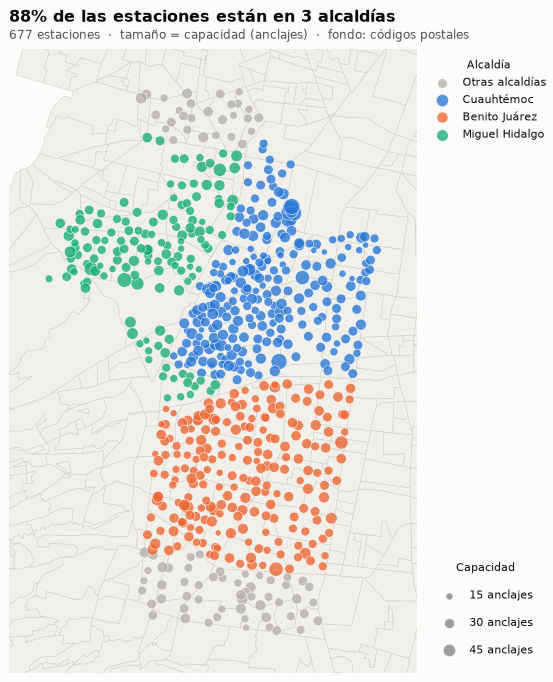

In [7]:
top3 = por_alcaldia.index[:3].tolist()
colores_alc = dict(zip(top3, [BLUE, ORANGE, AQUA]))
pct_top3 = por_alcaldia.loc[top3, "% estaciones"].sum()

fig, ax = plt.subplots(figsize=(8, 9))
plot_mapa_base(ax)
otras = ~est["alcaldia"].isin(top3)
ax.scatter(est.loc[otras, "lon"], est.loc[otras, "lat"], s=est.loc[otras, "capacidad"] * 2.2,
           color=GRIS_OTRAS, alpha=0.8, edgecolors="white", linewidths=0.5, label="Otras alcaldías", zorder=3)
for alc in top3:
    m = est["alcaldia"] == alc
    ax.scatter(est.loc[m, "lon"], est.loc[m, "lat"], s=est.loc[m, "capacidad"] * 2.2,
               color=colores_alc[alc], alpha=0.8, edgecolors="white", linewidths=0.5, label=alc, zorder=3)
ley = ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), frameon=True, facecolor=SURFACE, edgecolor="none", fontsize=9, title="Alcaldía", title_fontsize=9)
ax.add_artist(ley)
leyenda_tamanos(ax, [15, 30, 45], 2.2, lambda v: f"{v} anclajes", "Capacidad", color=INK_2)
titular(ax, f"{pct_top3:.0f}% de las estaciones están en 3 alcaldías",
        f"{len(est)} estaciones  ·  tamaño = capacidad (anclajes)  ·  fondo: códigos postales")
plt.show()

### Huecos de cobertura: distancia a la estación vecina más cercana

count   677.00
mean    219.00
std      85.00
min      14.00
50%     220.00
90%     324.00
95%     347.00
max     474.00
Name: vecina_m, dtype: float64


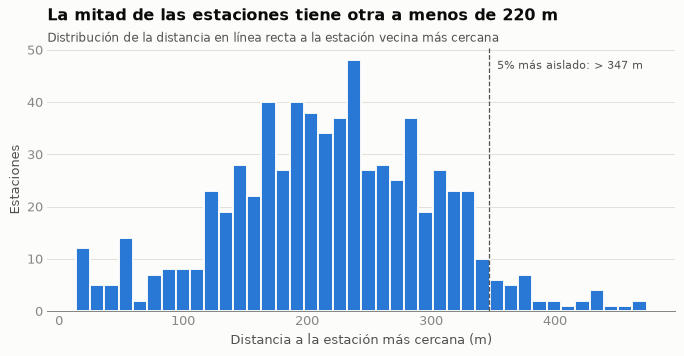

In [8]:
lat, lon = est["lat"].to_numpy(), est["lon"].to_numpy()
dist = haversine_m(lat[:, None], lon[:, None], lat[None, :], lon[None, :])
np.fill_diagonal(dist, np.inf)
est["vecina_m"] = dist.min(axis=1)
umbral_aislada = est["vecina_m"].quantile(0.95)
print(est["vecina_m"].describe(percentiles=[0.5, 0.9, 0.95]).round(0))

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.hist(est["vecina_m"], bins=40, color=BLUE, edgecolor=SURFACE, linewidth=1.5)
ax.axvline(umbral_aislada, color=INK_2, linestyle="--", linewidth=1)
ax.text(umbral_aislada, ax.get_ylim()[1] * 0.92, f"  5% más aislado: > {umbral_aislada:,.0f} m", color=INK_2, fontsize=9)
ax.set_xlabel("Distancia a la estación más cercana (m)")
ax.set_ylabel("Estaciones")
limpiar_ejes(ax)
titular(ax, f"La mitad de las estaciones tiene otra a menos de {est['vecina_m'].median():,.0f} m",
        "Distribución de la distancia en línea recta a la estación vecina más cercana")
plt.show()

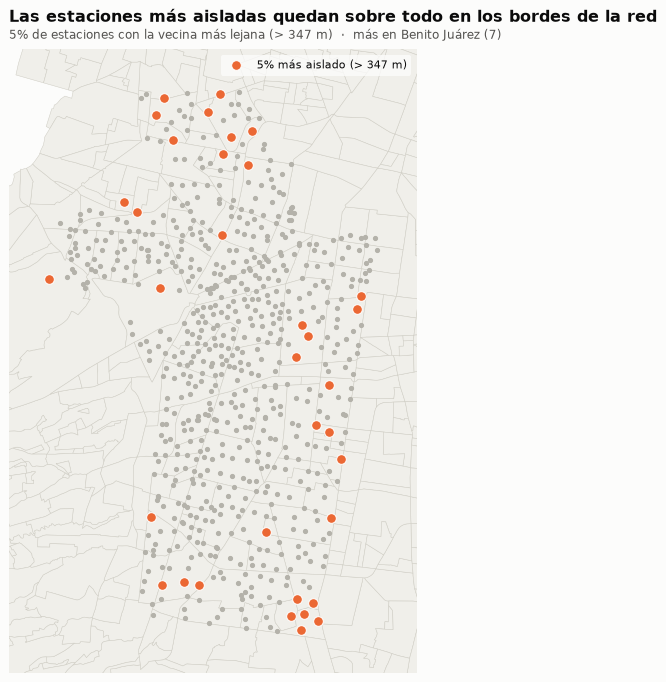

,ce,nombre,colonia,alcaldia,vecina_m
660,515,CE-515 Tebas-C. Salónica,Del Recreo / Nextengo,Azcapotzalco,473.92
201,457,CE-457 Av. Prado Norte-Explanada,Lomas de Chapultepec (8 colonias),Miguel Hidalgo,468.01
159,195,CE-195 Reforma-Circuito Mahatma Gandhi,Bosque de Chapultepec I Sección,Miguel Hidalgo,454.42
571,512,CE-512 Clavería - Floresta,Clavería / Sector Naval,Azcapotzalco,449.02
514,651,CE-651 Héroes del 47 - División del Norte,San Diego Churubusco / San Mateo,Coyoacán,436.55
487,709,CE-709 Inglaterra - Antigua Taxqueña,Parque San Andrés,Coyoacán,433.72
581,521,CE-521 Yuca - Clavelinas,San Bernabé,Azcapotzalco,432.05
299,465,CE-465 Lago Ginebra-Lago Wetter,Pensil Sur / Cuauhtémoc Pensil,Miguel Hidalgo,429.19
386,669,CE-669 Los Juarez - Sagredo,San José Insurgentes,Benito Juárez,425.45
512,609,CE-609 Romero - Calzada de Tlalpan,Américas Unidas,Benito Juárez,423.39


In [9]:
aisladas = est["vecina_m"] >= umbral_aislada
fig, ax = plt.subplots(figsize=(8, 9))
plot_mapa_base(ax)
ax.scatter(est.loc[~aisladas, "lon"], est.loc[~aisladas, "lat"], s=10, color=GRIS_OTRAS, zorder=3)
ax.scatter(est.loc[aisladas, "lon"], est.loc[aisladas, "lat"], s=60, color=ORANGE,
           edgecolors="white", linewidths=0.8, zorder=4, label=f"5% más aislado (> {umbral_aislada:,.0f} m)")
ax.legend(loc="upper right", frameon=True, facecolor=SURFACE, edgecolor="none", fontsize=9)
alc_aisladas = est.loc[aisladas, "alcaldia"].value_counts()
titular(ax, "Las estaciones más aisladas quedan sobre todo en los bordes de la red",
        f"5% de estaciones con la vecina más lejana (> {umbral_aislada:,.0f} m)  ·  más en {alc_aisladas.index[0]} ({alc_aisladas.iloc[0]})")
plt.show()
display(est.loc[aisladas, ["ce", "nombre", "colonia", "alcaldia", "vecina_m"]].sort_values("vecina_m", ascending=False).head(10))

## 3. Dónde está la demanda

Demanda = **salidas** (viajes que empiezan en la estación), promedio por día del periodo.

Las zonas se nombran por su colonia (`etiqueta_cp`); en tablas va el código postal entre paréntesis,
porque algunas colonias se llaman igual que una alcaldía (colonia Cuauhtémoc, colonia Juárez).

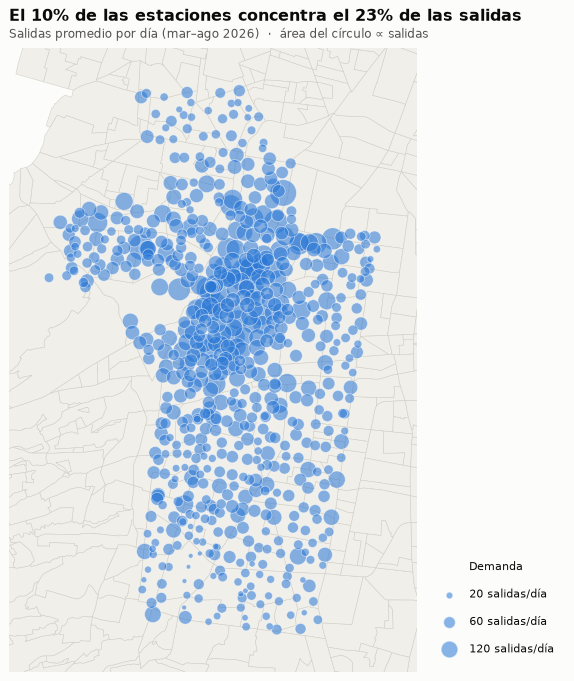

,nombre,colonia,alcaldia,salidas_dia
539,CE-548 Dr. Mariano Azuela - Jose Antonio Alzate,Santa María la Ribera,Cuauhtémoc,295.18
270,CE-027 Reforma- Havre,Juárez,Cuauhtémoc,280.95
304,CE-208 Hesiodo-Lamartine,Polanco V Sección,Miguel Hidalgo,270.86
76,CE-064 Sonora - Ámsterdam,Hipódromo,Cuauhtémoc,260.20
287,CE-038 Cozumel - Puebla,Roma Norte,Cuauhtémoc,236.08


In [10]:
salidas_est = validos.loc[o_ok].groupby("estacion_origen", observed=True).size()
demanda = est[["ce", "nombre"]].copy()
demanda["salidas_dia"] = por_estacion(salidas_est) / n_dias
demanda = unir_geo(demanda, col_id="ce")
demanda["colonia"] = etiqueta_cp(demanda["cp"], con_cp=False)

escala = 450 / demanda["salidas_dia"].max()
top5 = demanda.nlargest(5, "salidas_dia")
fig, ax = plt.subplots(figsize=(8, 9))
plot_mapa_base(ax)
d = demanda.sort_values("salidas_dia", ascending=False)  # grandes abajo, chicas encima
ax.scatter(d["lon"], d["lat"], s=d["salidas_dia"] * escala, color=BLUE, alpha=0.55,
           edgecolors="white", linewidths=0.6, zorder=3)
leyenda_tamanos(ax, [20, 60, 120], escala, lambda v: f"{v} salidas/día", "Demanda")
pct_top10 = demanda.nlargest(int(len(demanda) * 0.1), "salidas_dia")["salidas_dia"].sum() / demanda["salidas_dia"].sum() * 100
titular(ax, f"El 10% de las estaciones concentra el {pct_top10:.0f}% de las salidas",
        "Salidas promedio por día (mar–ago 2026)  ·  área del círculo ∝ salidas")
plt.show()
display(top5[["nombre", "colonia", "alcaldia", "salidas_dia"]])

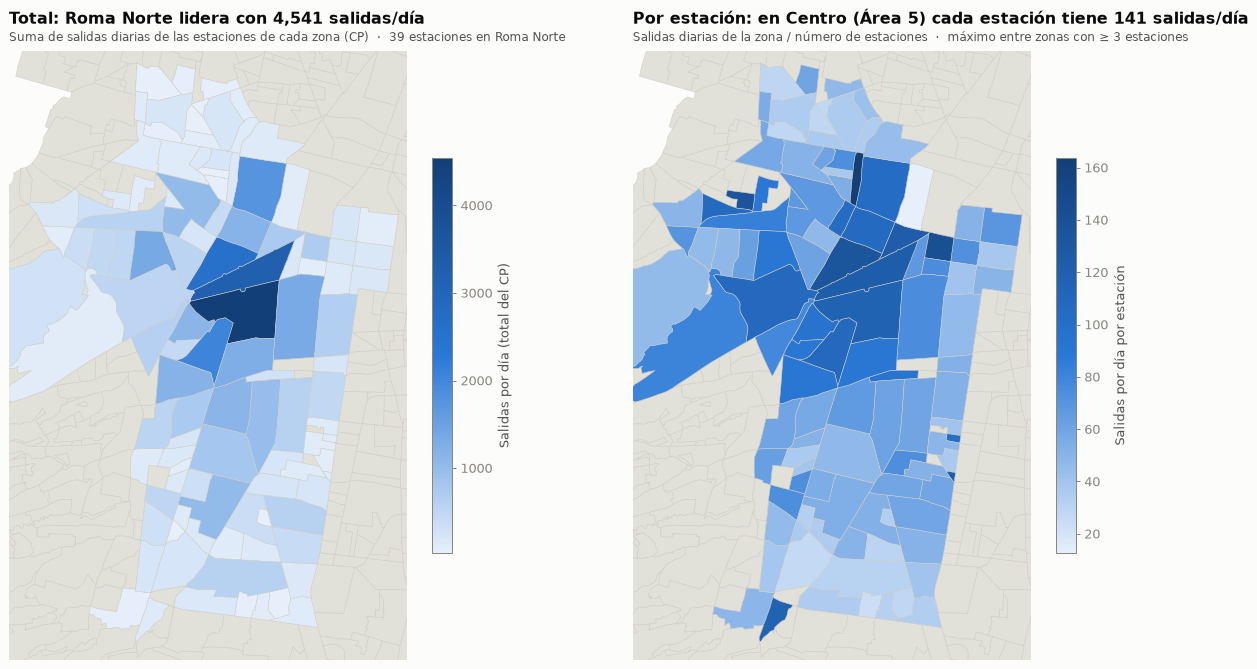

,salidas_dia,estaciones,por_estacion
zona (CP),,,
Roma Norte (06700),"4,541.12",39,116.44
Juárez (06600),"3,236.90",26,124.50
Cuauhtémoc (06500),"2,554.16",19,134.43
Hipódromo (06100),"2,053.48",19,108.08
Santa María la Ribera (06400),"1,741.32",17,102.43
Polanco V Sección (11560),"1,351.22",15,90.08
Doctores (06720),"1,342.60",18,74.59
Roma Sur (06760),"1,264.94",14,90.35


,salidas_dia,estaciones,por_estacion
zona (CP),,,
Centro (Área 5) (06050),704.18,5,140.84
Cuauhtémoc (06500),"2,554.16",19,134.43
Juárez (06600),"3,236.90",26,124.50
Tabacalera (06030),739.25,6,123.21
Roma Norte (06700),"4,541.12",39,116.44
Hipódromo (06100),"2,053.48",19,108.08
Bosque de Chapultepec I Sección (11580),539.01,5,107.80
Ampliación Granada (11529),319.32,3,106.44


In [11]:
por_cp = demanda.groupby("cp").agg(salidas_dia=("salidas_dia", "sum"), estaciones=("ce", "size"))
por_cp["por_estacion"] = por_cp["salidas_dia"] / por_cp["estaciones"]

fig, axes = plt.subplots(1, 2, figsize=(14, 8.5))
_, m1 = plot_mapa_base(axes[0], valores=por_cp["salidas_dia"])
fig.colorbar(m1, ax=axes[0], shrink=0.55, label="Salidas por día (total del CP)")
cp1 = por_cp["salidas_dia"].idxmax()
titular(axes[0], f"Total: {etiqueta_cp(cp1, con_cp=False)} lidera con {por_cp.loc[cp1, 'salidas_dia']:,.0f} salidas/día",
        f"Suma de salidas diarias de las estaciones de cada zona (CP)  ·  {por_cp.loc[cp1, 'estaciones']} estaciones en {etiqueta_cp(cp1, con_cp=False)}")

_, m2 = plot_mapa_base(axes[1], valores=por_cp["por_estacion"])
fig.colorbar(m2, ax=axes[1], shrink=0.55, label="Salidas por día por estación")
cp2 = por_cp.loc[por_cp["estaciones"] >= 3, "por_estacion"].idxmax()
titular(axes[1], f"Por estación: en {etiqueta_cp(cp2, con_cp=False)} cada estación tiene {por_cp.loc[cp2, 'por_estacion']:,.0f} salidas/día",
        "Salidas diarias de la zona / número de estaciones  ·  máximo entre zonas con ≥ 3 estaciones")
plt.tight_layout()
plt.show()
tabla_cp = por_cp.copy()
tabla_cp.index = etiqueta_cp(tabla_cp.index)
tabla_cp.index.name = "zona (CP)"
display(tabla_cp.sort_values("salidas_dia", ascending=False).head(8))
display(tabla_cp[tabla_cp["estaciones"] >= 3].sort_values("por_estacion", ascending=False).head(8))

## 4. Cuándo y dónde

### Franjas horarias
Para cada franja se calcula qué **% de las salidas de esa franja** ocurre en cada zona (código postal).
Así los cuatro mapas suman 100% cada uno y comparten la misma escala de color: lo que cambia es
*a dónde se mueve* la demanda, no cuánta hay.

Suma por franja (debe ser 100): [100.0, 100.0, 100.0, 100.0]


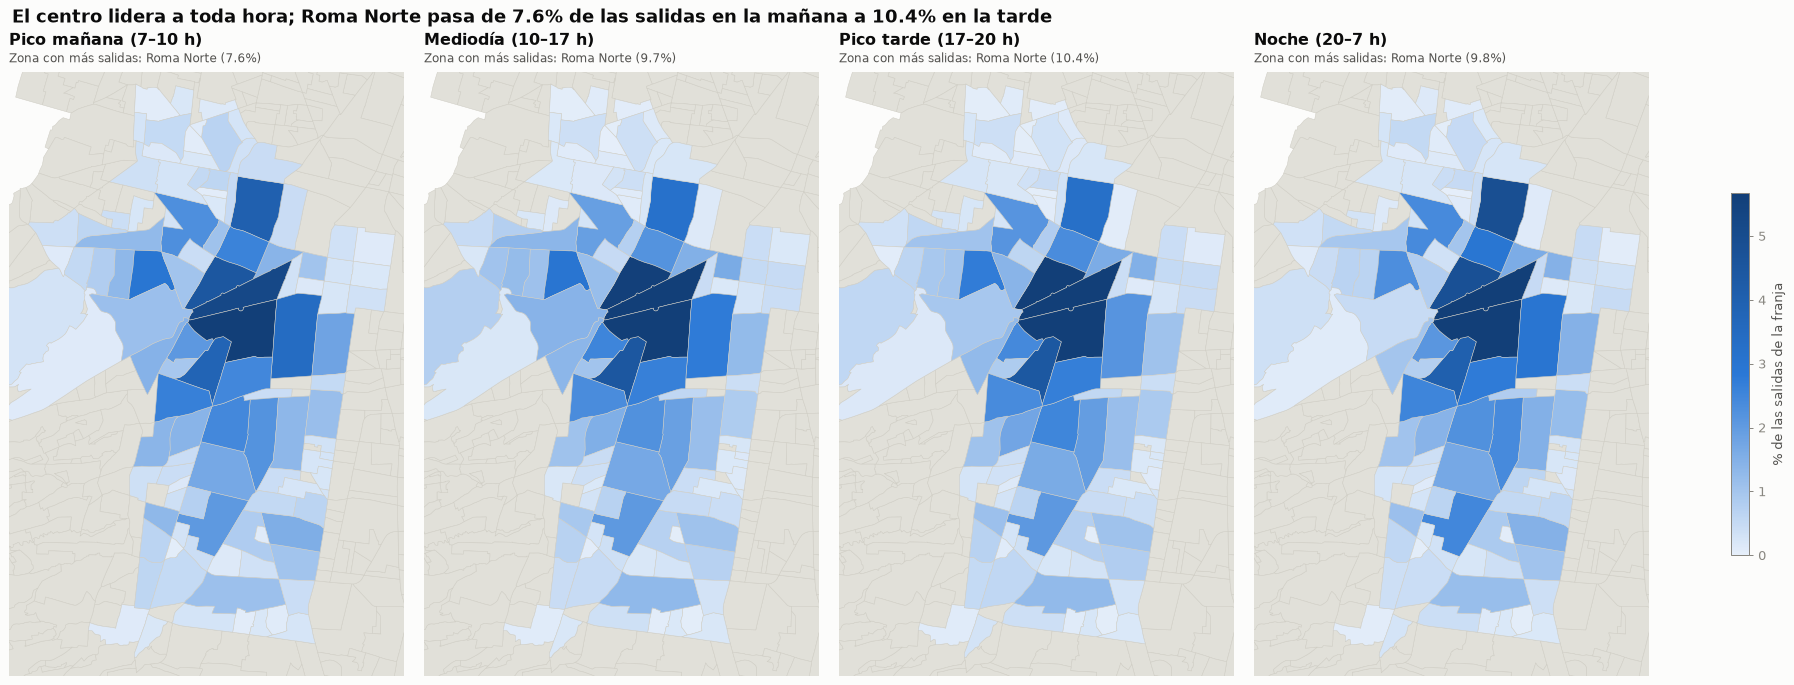

Zonas que ganan peso en la TARDE vs la mañana (puntos porcentuales):
cp
Roma Norte (06700)        -2.83
Juárez (06600)            -2.46
Cuauhtémoc (06500)        -1.45
Hipódromo (06100)         -0.61
Centro (Área 5) (06050)   -0.50

Zonas que ganan peso en la MAÑANA vs la tarde:
cp
Doctores (06720)                1.26
Santa María la Ribera (06400)   0.79
Obrera (06800)                  0.72
Portales Norte (03303)          0.49
Buenavista (06350)              0.36


In [12]:
FRANJAS = {"Pico mañana (7–10 h)": range(7, 10), "Mediodía (10–17 h)": range(10, 17),
           "Pico tarde (17–20 h)": range(17, 20), "Noche (20–7 h)": [*range(20, 24), *range(0, 7)]}
hora = validos.loc[o_ok, "hora_del_dia"]
ids_o = validos.loc[o_ok, "estacion_origen"]
franja_cp = {}
for nombre, horas in FRANJAS.items():
    s = ids_o[hora.isin(list(horas))].value_counts()
    tabla = est[["ce"]].copy()
    tabla["salidas"] = por_estacion(s)
    tabla = unir_geo(tabla, col_id="ce")
    cp_ = tabla.groupby("cp")["salidas"].sum()
    franja_cp[nombre] = cp_ / cp_.sum() * 100
franja_cp = pd.DataFrame(franja_cp)
print("Suma por franja (debe ser 100):", franja_cp.sum().round(6).tolist())

vmax = franja_cp.quantile(0.98).max()
fig, axes = plt.subplots(1, 4, figsize=(20, 7.5), layout="constrained")
for ax, nombre in zip(axes, franja_cp.columns):
    _, m = plot_mapa_base(ax, valores=franja_cp[nombre])
    m.set_clim(0, vmax)
    top = franja_cp[nombre].idxmax()
    titular(ax, nombre, f"Zona con más salidas: {etiqueta_cp(top, con_cp=False)} ({franja_cp.loc[top, nombre]:.1f}%)")
fig.colorbar(m, ax=axes.ravel().tolist(), shrink=0.6, label="% de las salidas de la franja")
cp_top = franja_cp.mean(axis=1).idxmax()
fig.suptitle(f"El centro lidera a toda hora; {etiqueta_cp(cp_top, con_cp=False)} pasa de {franja_cp.loc[cp_top].iloc[0]:.1f}% de las salidas "
             f"en la mañana a {franja_cp.loc[cp_top].iloc[2]:.1f}% en la tarde",
             x=0.01, ha="left", fontsize=14, fontweight="bold")
plt.show()

cambio = (franja_cp["Pico mañana (7–10 h)"] - franja_cp["Pico tarde (17–20 h)"]).sort_values()
cambio.index = etiqueta_cp(cambio.index)
print("Zonas que ganan peso en la TARDE vs la mañana (puntos porcentuales):")
print(cambio.head(5).round(2).to_string())
print("\nZonas que ganan peso en la MAÑANA vs la tarde:")
print(cambio.tail(5)[::-1].round(2).to_string())

### Entre semana vs fin de semana
Índice = (% de las salidas de la estación que ocurren en fin de semana) ÷ (% del sistema).
**1×** = igual que el promedio; **2×** = el doble de uso relativo en fin de semana. Solo estaciones
con al menos 500 salidas en el periodo.

Share de fin de semana en el sistema: 20.3%


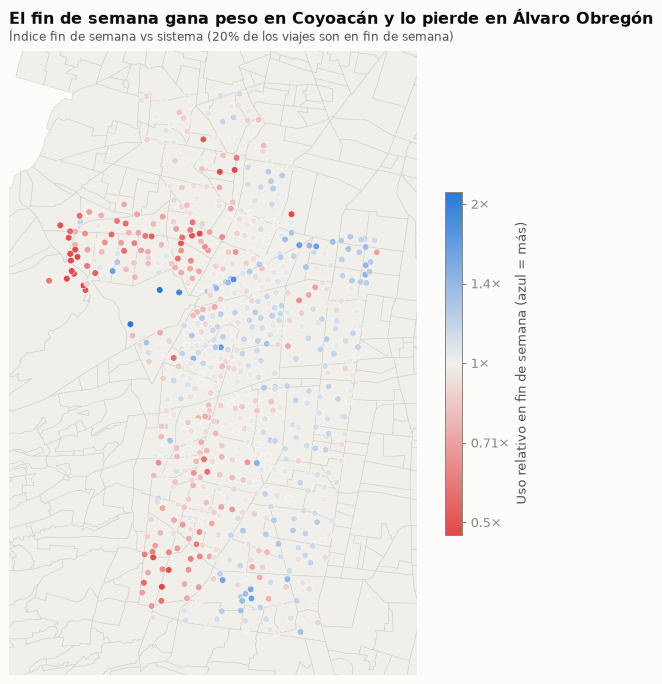

Índice ponderado por alcaldía:
alcaldia
Coyoacán         1.13
Cuauhtémoc       1.07
Azcapotzalco     1.00
Benito Juárez    0.97
Miguel Hidalgo   0.87
Álvaro Obregón   0.67


,nombre,alcaldia,total,indice_finde
99,CE-195 Reforma-Circuito Mahatma Gandhi,Miguel Hidalgo,23892,2.47
633,CE-710 Molino del Rey - Glorieta de la Lealtad,Miguel Hidalgo,19618,2.16
98,CE-194 Circuito Mahatma Gandhi-Reforma,Miguel Hidalgo,39558,1.91
156,CE-025 Reforma - Estocolmo,Cuauhtémoc,19661,1.82
307,CE-041 Reforma - Av. de la República,Cuauhtémoc,28395,1.66


In [13]:
sub = validos.loc[o_ok, ["estacion_origen", "es_fin_de_semana"]]
tabla = sub.groupby(["estacion_origen", "es_fin_de_semana"], observed=True).size().unstack(fill_value=0)
tabla.columns = ["entre_semana", "fin_de_semana"]
tabla["total"] = tabla.sum(axis=1)
share_sistema = tabla["fin_de_semana"].sum() / tabla["total"].sum()
tabla = tabla[tabla["total"] >= 500]
tabla["indice_finde"] = (tabla["fin_de_semana"] / tabla["total"]) / share_sistema
tabla = tabla.reset_index()
tabla["ce"] = tabla["estacion_origen"].astype(str)
tabla = unir_geo(tabla, col_id="ce")
tabla = tabla.merge(est[["ce", "nombre"]], on="ce")
print(f"Share de fin de semana en el sistema: {share_sistema:.1%}")

log_idx = np.log2(tabla["indice_finde"])
lim = np.abs(log_idx).quantile(0.98)
fig, ax = plt.subplots(figsize=(8, 9))
plot_mapa_base(ax)
sc = ax.scatter(tabla["lon"], tabla["lat"], c=log_idx.clip(-lim, lim), cmap=CMAP_DIVERGENTE,
                norm=TwoSlopeNorm(0, -lim, lim), s=28, edgecolors="white", linewidths=0.4, zorder=3)
cb = fig.colorbar(sc, ax=ax, shrink=0.55)
ticks = [t for t in [-1, -0.5, 0, 0.5, 1] if abs(t) <= lim + 1e-9]
cb.set_ticks(ticks)
cb.set_ticklabels([f"{2 ** t:.2g}×" for t in ticks])
cb.set_label("Uso relativo en fin de semana (azul = más)")
alc_finde = tabla.groupby("alcaldia").apply(lambda g: np.average(g["indice_finde"], weights=g["total"]), include_groups=False)
titular(ax, f"El fin de semana gana peso en {alc_finde.idxmax()} y lo pierde en {alc_finde.idxmin()}",
        f"Índice fin de semana vs sistema ({share_sistema:.0%} de los viajes son en fin de semana)")
plt.show()
print("Índice ponderado por alcaldía:")
print(alc_finde.sort_values(ascending=False).round(2).to_string())
display(tabla.nlargest(5, "indice_finde")[["nombre", "alcaldia", "total", "indice_finde"]])

## 5. Flujo neto: qué estaciones se vacían y cuáles se llenan

Flujo neto = **llegadas − salidas** en la ventana, promedio por **día hábil**. Negativo (rojo) = la
estación **se vacía** (salen más bicis de las que llegan); positivo (azul) = **se llena**.
Las salidas se cuentan por hora de salida y las llegadas por hora de llegada.

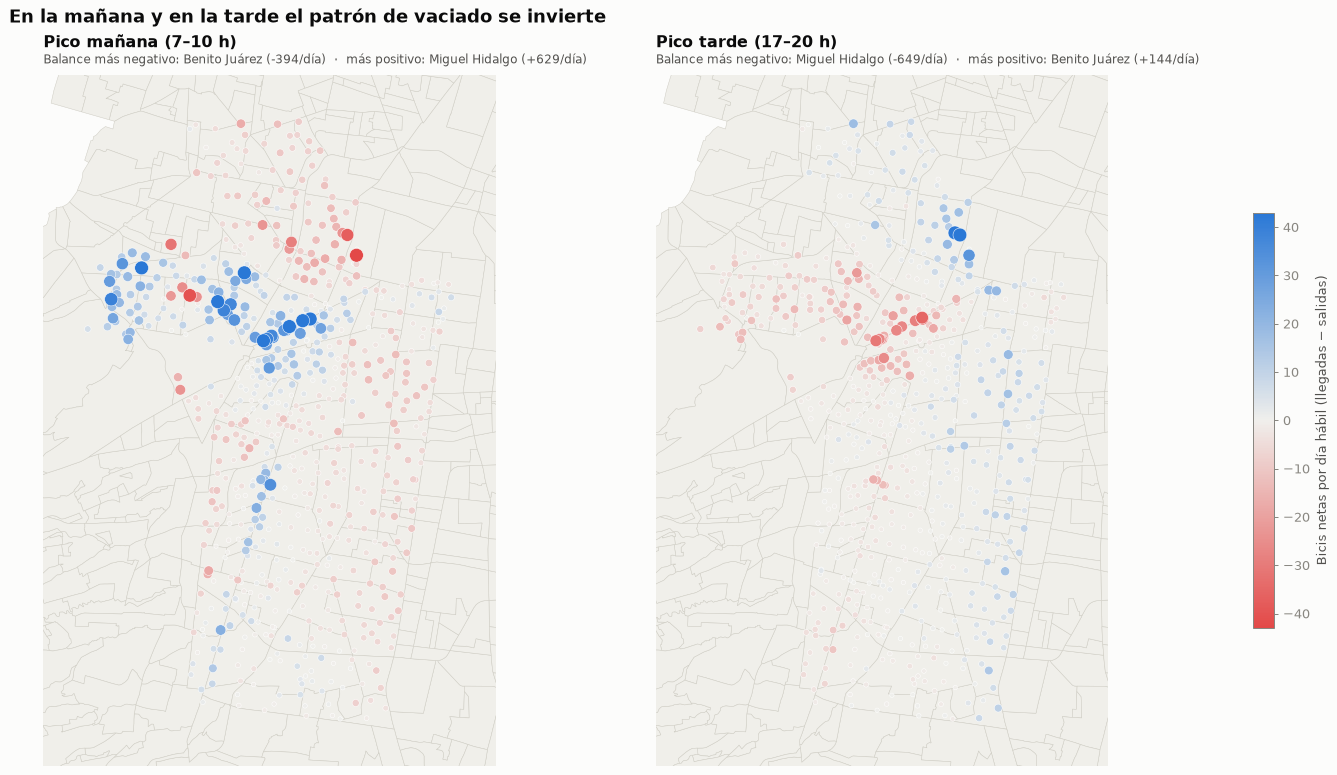

Correlación del flujo neto mañana vs tarde por estación: -0.74


In [14]:
habil = (~validos["es_fin_de_semana"]).to_numpy() & en_periodo.to_numpy()


def neto_pico(h0, h1):
    m_sal = habil & o_ok & validos["hora_del_dia"].between(h0, h1 - 1).to_numpy()
    m_lle = habil & d_ok & validos["hora_llegada"].between(h0, h1 - 1).to_numpy()
    sal = validos.loc[m_sal, "estacion_origen"].value_counts()
    lle = validos.loc[m_lle, "estacion_destino"].value_counts()
    t = est[["ce", "nombre"]].copy()
    t["salidas_dia"] = por_estacion(sal) / n_dias_habiles
    t["llegadas_dia"] = por_estacion(lle) / n_dias_habiles
    t["neto_dia"] = t["llegadas_dia"] - t["salidas_dia"]
    t = unir_geo(t, col_id="ce")
    t["colonia"] = etiqueta_cp(t["cp"], con_cp=False)
    return t


netos = {"Pico mañana (7–10 h)": neto_pico(7, 10), "Pico tarde (17–20 h)": neto_pico(17, 20)}
lim = max(np.abs(t["neto_dia"]).quantile(0.99) for t in netos.values())
norm = TwoSlopeNorm(0, -lim, lim)

fig, axes = plt.subplots(1, 2, figsize=(15, 8.5), layout="constrained")
for ax, (nombre, t) in zip(axes, netos.items()):
    plot_mapa_base(ax)
    t = t.reindex(t["neto_dia"].abs().sort_values().index)
    sc = ax.scatter(t["lon"], t["lat"], c=t["neto_dia"].clip(-lim, lim), cmap=CMAP_DIVERGENTE, norm=norm,
                    s=12 + 110 * (t["neto_dia"].abs() / lim).clip(0, 1), edgecolors="white", linewidths=0.4, zorder=3)
    balance = t.groupby("alcaldia")["neto_dia"].sum()
    titular(ax, nombre, f"Balance más negativo: {balance.idxmin()} ({balance.min():+,.0f}/día)  ·  "
                        f"más positivo: {balance.idxmax()} ({balance.max():+,.0f}/día)")
fig.colorbar(sc, ax=axes.ravel().tolist(), shrink=0.6, label="Bicis netas por día hábil (llegadas − salidas)")
fig.suptitle("En la mañana y en la tarde el patrón de vaciado se invierte", x=0.02, ha="left", fontsize=14, fontweight="bold")
plt.show()

corr = np.corrcoef(netos["Pico mañana (7–10 h)"]["neto_dia"], netos["Pico tarde (17–20 h)"]["neto_dia"])[0, 1]
print(f"Correlación del flujo neto mañana vs tarde por estación: {corr:.2f}")

In [15]:
for nombre, t in netos.items():
    print(f"\n{nombre}: 10 estaciones con mayor déficit (se vacían)")
    display(t.nsmallest(10, "neto_dia")[["nombre", "colonia", "alcaldia", "salidas_dia", "llegadas_dia", "neto_dia"]])


Pico mañana (7–10 h): 10 estaciones con mayor déficit (se vacían)


,nombre,colonia,alcaldia,salidas_dia,llegadas_dia,neto_dia
296,CE-176 Av. Jesús García-Luis Donaldo Colosio,Buenavista,Cuauhtémoc,44.77,1.85,-42.92
304,CE-208 Hesiodo-Lamartine,Polanco V Sección,Miguel Hidalgo,80.73,40.31,-40.43
539,CE-548 Dr. Mariano Azuela - Jose Antonio Alzate,Santa María la Ribera,Cuauhtémoc,72.71,35.69,-37.02
299,CE-465 Lago Ginebra-Lago Wetter,Pensil Sur / Cuauhtémoc Pensil,Miguel Hidalgo,45.33,14.09,-31.24
457,CE-495 Amado Nervo - de los Maestros,Agricultura,Miguel Hidalgo,58.40,29.72,-28.68
142,CE-204 Temístocles-Homero,Polanco IV Sección,Miguel Hidalgo,37.49,12.06,-25.43
293,CE-211 Isaac Newton-Horacio,Polanco V Sección,Miguel Hidalgo,40.64,16.40,-24.24
653,CE-547 Dr. Enrique González Martínez - Salvado...,Santa María la Ribera,Cuauhtémoc,30.72,7.00,-23.72
673,CE-711 Molino del Rey - Av. Constituyentes,Bosque de Chapultepec I Sección,Miguel Hidalgo,34.40,10.75,-23.66
468,CE-492 Lago Cuitzeo - Felipe Carrillo Puerto,Anáhuac I Sección / Anáhuac II Sección,Miguel Hidalgo,35.95,12.69,-23.26



Pico tarde (17–20 h): 10 estaciones con mayor déficit (se vacían)


,nombre,colonia,alcaldia,salidas_dia,llegadas_dia,neto_dia
115,CE-019 Reforma - Río Rhin,Cuauhtémoc,Cuauhtémoc,54.24,18.90,-35.34
270,CE-027 Reforma- Havre,Juárez,Cuauhtémoc,89.35,57.23,-32.12
259,CE-014 Reforma - Río de Plata,Cuauhtémoc,Cuauhtémoc,65.14,34.49,-30.65
286,CE-018 Reforma - Río Rhin,Cuauhtémoc,Cuauhtémoc,60.65,32.02,-28.63
112,CE-016 Reforma - Río Tiber,Cuauhtémoc,Cuauhtémoc,42.40,15.29,-27.11
255,CE-017 Reforma - Río Tiber,Cuauhtémoc,Cuauhtémoc,50.78,24.03,-26.75
117,CE-261 Paseo de la Reforma-Río de la Plata,Cuauhtémoc,Cuauhtémoc,31.44,4.91,-26.53
287,CE-038 Cozumel - Puebla,Roma Norte,Cuauhtémoc,81.40,55.87,-25.53
9,CE-022 Reforma - Manchester,Juárez,Cuauhtémoc,32.55,8.49,-24.06
307,CE-021 Reforma - Dublín,Juárez,Cuauhtémoc,34.58,12.40,-22.18


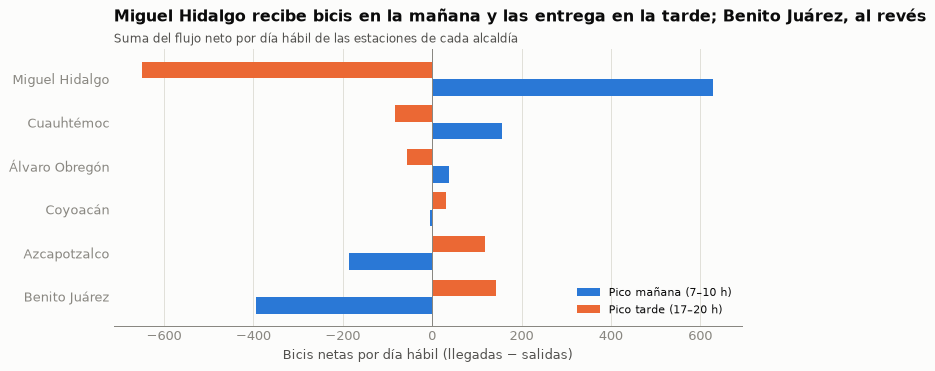

,Pico mañana (7–10 h),Pico tarde (17–20 h)
alcaldia,,
Benito Juárez,-393.60,143.90
Azcapotzalco,-185.60,118.90
Coyoacán,-4.30,31.30
Álvaro Obregón,37.30,-55.20
Cuauhtémoc,155.40,-83.00
Miguel Hidalgo,628.60,-648.50


In [16]:
por_alc = pd.DataFrame({n: t.groupby("alcaldia")["neto_dia"].sum() for n, t in netos.items()}).sort_values("Pico mañana (7–10 h)")
fig, ax = plt.subplots(figsize=(9, 4))
y = np.arange(len(por_alc))
ax.barh(y - 0.2, por_alc.iloc[:, 0], height=0.38, color=BLUE, label=por_alc.columns[0])
ax.barh(y + 0.2, por_alc.iloc[:, 1], height=0.38, color=ORANGE, label=por_alc.columns[1])
ax.set_yticks(y, por_alc.index)
ax.axvline(0, color=MUTED, linewidth=0.8)
ax.set_xlabel("Bicis netas por día hábil (llegadas − salidas)")
ax.legend(frameon=False, fontsize=9, loc="lower right")
for s in ["top", "right", "left"]:
    ax.spines[s].set_visible(False)
ax.xaxis.grid(True, color=GRID)
ax.set_axisbelow(True)
ax.tick_params(length=0)
recibe, entrega = por_alc.iloc[:, 0].idxmax(), por_alc.iloc[:, 0].idxmin()
titular(ax, f"{recibe} recibe bicis en la mañana y las entrega en la tarde; {entrega}, al revés",
        "Suma del flujo neto por día hábil de las estaciones de cada alcaldía")
plt.show()
display(por_alc.round(1))

## 6. Origen–destino

Se agrega por **par de estaciones** (origen, destino) con su conteo de viajes y luego se une la
geografía de cada extremo con `unir_geo(..., prefijo="origen_")` y `prefijo="destino_"`.

Pares origen-destino distintos: 302,114  ·  viajes: 8,480,184
Viajes dentro de la misma alcaldía: 71.3%
Suma por fila (debe ser 100): [100.0, 100.0, 100.0, 100.0, 100.0, 100.0]


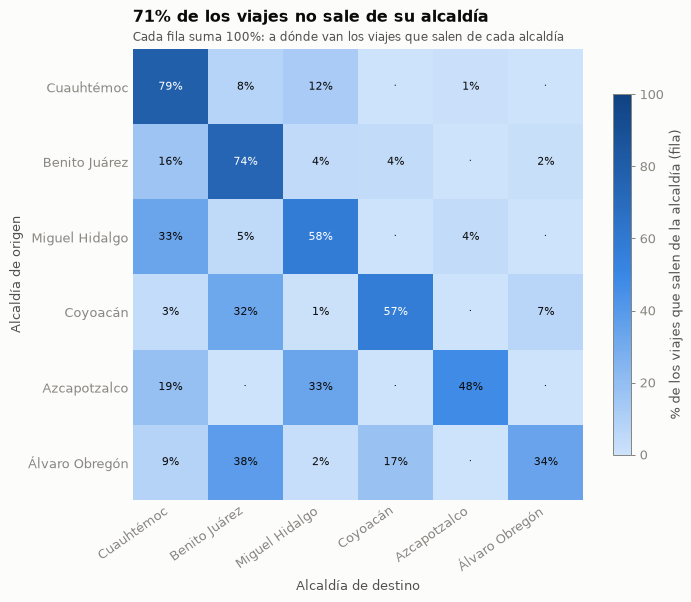

In [17]:
ok = o_ok & d_ok
pares = (validos.loc[ok].groupby(["estacion_origen", "estacion_destino"], observed=True).size()
         .rename("viajes").reset_index())
pares = unir_geo(pares, "estacion_origen", prefijo="origen_")
pares = unir_geo(pares, "estacion_destino", prefijo="destino_")
print(f"Pares origen-destino distintos: {len(pares):,}  ·  viajes: {pares['viajes'].sum():,}")

matriz = pares.pivot_table(index="origen_alcaldia", columns="destino_alcaldia", values="viajes", aggfunc="sum", fill_value=0)
orden = matriz.sum(axis=1).sort_values(ascending=False).index
matriz = matriz.loc[orden, orden]
matriz_pct = matriz.div(matriz.sum(axis=1), axis=0) * 100
intra = np.trace(matriz.to_numpy()) / matriz.to_numpy().sum() * 100
print(f"Viajes dentro de la misma alcaldía: {intra:.1f}%")
print("Suma por fila (debe ser 100):", matriz_pct.sum(axis=1).round(6).tolist())

fig, ax = plt.subplots(figsize=(8.5, 6.5))
im = ax.imshow(matriz_pct.to_numpy(), cmap=CMAP_SECUENCIAL, vmin=0, vmax=100)
ax.set_xticks(range(len(orden)), orden, rotation=35, ha="right")
ax.set_yticks(range(len(orden)), orden)
for i in range(len(orden)):
    for j in range(len(orden)):
        v = matriz_pct.iat[i, j]
        ax.text(j, i, f"{v:.0f}%" if v >= 0.5 else "·", ha="center", va="center", fontsize=9,
                color="white" if v > 55 else INK)
ax.set_xlabel("Alcaldía de destino")
ax.set_ylabel("Alcaldía de origen")
for s in ax.spines.values():
    s.set_visible(False)
ax.tick_params(length=0)
fig.colorbar(im, ax=ax, shrink=0.8, label="% de los viajes que salen de la alcaldía (fila)")
titular(ax, f"{intra:.0f}% de los viajes no sale de su alcaldía", "Cada fila suma 100%: a dónde van los viajes que salen de cada alcaldía")
plt.show()

Distancia en línea recta (viajes no circulares): mediana 1.49 km  ·  p90 3.78 km


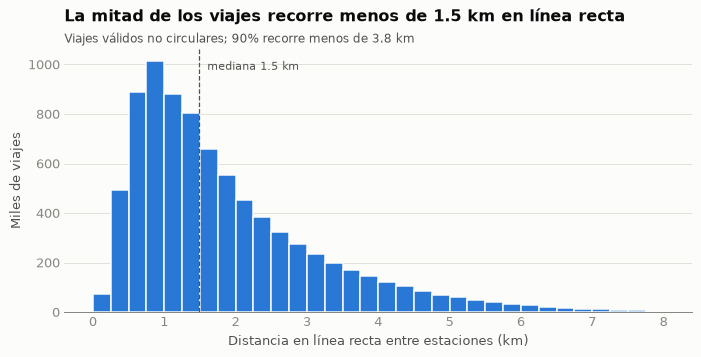

In [18]:
circular = pares["origen_lat"].notna() & (pares["estacion_origen"].astype(str) == pares["estacion_destino"].astype(str))
no_circ = pares[~circular].copy()
no_circ["km"] = haversine_m(no_circ["origen_lat"], no_circ["origen_lon"], no_circ["destino_lat"], no_circ["destino_lon"]) / 1000
med_km = mediana_ponderada(no_circ["km"].to_numpy(), no_circ["viajes"].to_numpy())
p90_km = np.interp(0.9, np.cumsum(no_circ.sort_values("km")["viajes"]) / no_circ["viajes"].sum(), no_circ.sort_values("km")["km"])
print(f"Distancia en línea recta (viajes no circulares): mediana {med_km:.2f} km  ·  p90 {p90_km:.2f} km")

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.hist(no_circ["km"], bins=np.arange(0, 8.25, 0.25), weights=no_circ["viajes"] / 1000, color=BLUE, edgecolor=SURFACE, linewidth=1.2)
ax.axvline(med_km, color=INK_2, linestyle="--", linewidth=1)
ax.text(med_km, ax.get_ylim()[1] * 0.92, f"  mediana {med_km:.1f} km", color=INK_2, fontsize=9)
ax.set_xlabel("Distancia en línea recta entre estaciones (km)")
ax.set_ylabel("Miles de viajes")
limpiar_ejes(ax)
titular(ax, f"La mitad de los viajes recorre menos de {med_km:.1f} km en línea recta",
        f"Viajes válidos no circulares; 90% recorre menos de {p90_km:.1f} km")
plt.show()

Viajes circulares (misma estación de origen y destino): 2.7% del total


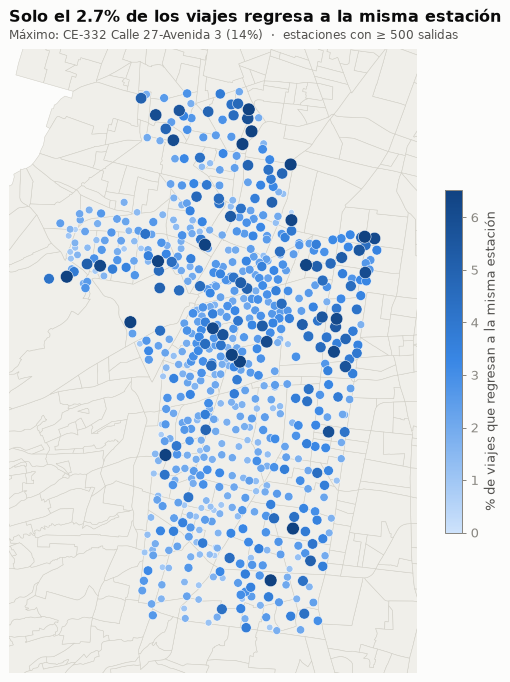

,nombre,alcaldia,total,pct_circular
236,CE-332 Calle 27-Avenida 3,Benito Juárez,5636,13.82
56,CE-152 Tlacotalpan-Campeche,Cuauhtémoc,17165,12.96
570,CE-654 Londres - San Pedro,Coyoacán,4857,12.27
633,CE-710 Molino del Rey - Glorieta de la Lealtad,Miguel Hidalgo,18706,12.10
428,CE-526 Toronjil - Mejorana,Azcapotzalco,4296,9.40
133,CE-225 Petrarca-Presidente Masaryk,Miguel Hidalgo,12421,8.68
438,CE-535 Av. Jardín - Orquídea,Azcapotzalco,5745,8.18
170,CE-262 República de Cuba-República de Brasil,Cuauhtémoc,8214,7.60


In [19]:
circ_est = pares[circular].groupby(pares.loc[circular, "estacion_origen"].astype(str))["viajes"].sum()
tot_est = pares.groupby(pares["estacion_origen"].astype(str))["viajes"].sum()
circ = pd.DataFrame({"circulares": circ_est, "total": tot_est}).fillna(0)
pct_circ_sistema = circ["circulares"].sum() / circ["total"].sum() * 100
circ = circ[circ["total"] >= 500]
circ["pct_circular"] = circ["circulares"] / circ["total"] * 100
circ = unir_geo(circ.rename_axis("ce").reset_index(), col_id="ce")
circ = circ.merge(est[["ce", "nombre"]], on="ce")
print(f"Viajes circulares (misma estación de origen y destino): {pct_circ_sistema:.1f}% del total")

fig, ax = plt.subplots(figsize=(8, 9))
plot_mapa_base(ax)
c = circ.sort_values("pct_circular")
vmax_c = c["pct_circular"].quantile(0.98)
sc = ax.scatter(c["lon"], c["lat"], c=c["pct_circular"].clip(upper=vmax_c), cmap=CMAP_SECUENCIAL, vmin=0, vmax=vmax_c,
                s=14 + 90 * (c["pct_circular"] / vmax_c).clip(0, 1), edgecolors="white", linewidths=0.4, zorder=3)
fig.colorbar(sc, ax=ax, shrink=0.55, label="% de viajes que regresan a la misma estación")
top_c = circ.nlargest(1, "pct_circular").iloc[0]
titular(ax, f"Solo el {pct_circ_sistema:.1f}% de los viajes regresa a la misma estación",
        f"Máximo: {top_c['nombre']} ({top_c['pct_circular']:.0f}%)  ·  estaciones con ≥ 500 salidas")
plt.show()
display(circ.nlargest(8, "pct_circular")[["nombre", "alcaldia", "total", "pct_circular"]])

## 7. Foto del estado actual (snapshot GBFS)

> ⚠️ Es **un solo instante** capturado al correr `src/stations.py`, no un patrón. Sirve para ver
> cómo se ve el sistema en vivo y, más adelante, compararlo contra la predicción del modelo.

Snapshot: 2026-09-26 20:05  ·  estaciones vacías: 72  ·  llenas: 17  ·  de 677


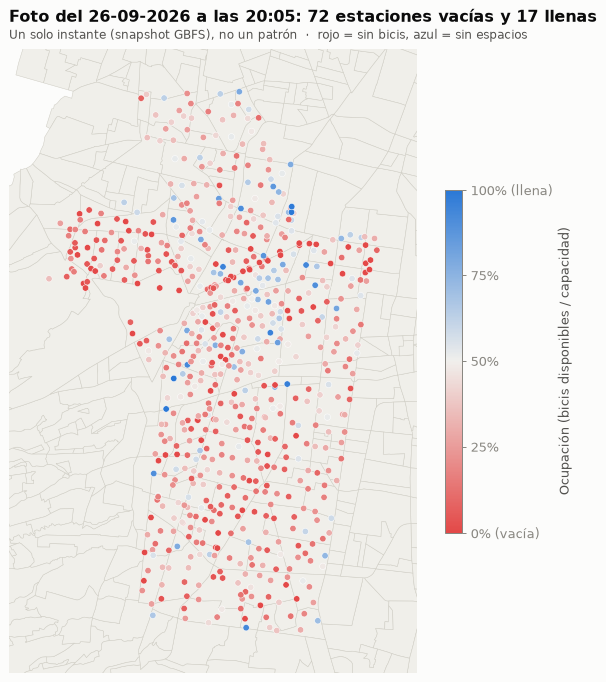

In [20]:
snap = load_status_snapshot()
snap = unir_geo(snap, col_id="station_id", clave="station_id")  # el snapshot es GBFS
snap["capacidad"] = snap["station_id"].map(est.set_index("station_id")["capacidad"])
snap["ocupacion"] = (snap["bicis_disponibles"] / snap["capacidad"].where(snap["capacidad"] > 0)).clip(0, 1)
momento = pd.Timestamp(snap["timestamp_snapshot"].iloc[0])
vacias = (snap["bicis_disponibles"] == 0).sum()
llenas = (snap["espacios_disponibles"] == 0).sum()
print(f"Snapshot: {momento:%Y-%m-%d %H:%M}  ·  estaciones vacías: {vacias}  ·  llenas: {llenas}  ·  de {len(snap)}")

fig, ax = plt.subplots(figsize=(8, 9))
plot_mapa_base(ax)
s = snap.dropna(subset=["ocupacion", "lat"])
sc = ax.scatter(s["lon"], s["lat"], c=s["ocupacion"], cmap=CMAP_DIVERGENTE, norm=TwoSlopeNorm(0.5, 0, 1),
                s=26, edgecolors="white", linewidths=0.4, zorder=3)
cb = fig.colorbar(sc, ax=ax, shrink=0.55, label="Ocupación (bicis disponibles / capacidad)")
cb.set_ticks([0, 0.25, 0.5, 0.75, 1], labels=["0% (vacía)", "25%", "50%", "75%", "100% (llena)"])
titular(ax, f"Foto del {momento:%d-%m-%Y a las %H:%M}: {vacias} estaciones vacías y {llenas} llenas",
        "Un solo instante (snapshot GBFS), no un patrón  ·  rojo = sin bicis, azul = sin espacios")
plt.show()

## 8. Hallazgos

Resumen de lo que muestran los datos (mar–ago 2026, 9.16 M viajes válidos). Cada punto remite a una
salida o gráfica de arriba.

**La red**
- **88% de las estaciones están en 3 alcaldías**: Cuauhtémoc (243), Benito Juárez (213) y Miguel Hidalgo (139).
- La red es densa: la mitad de las estaciones tiene otra a menos de **220 m**. El 5% más aislado
  (> 347 m de su vecina) queda sobre todo en los bordes de la red.

**Dónde está la demanda**
- La demanda está concentrada: **el 10% de las estaciones genera el 23% de las salidas**.
- **Roma Norte** lidera con **4,541 salidas/día** (39 estaciones), seguida de la colonia Juárez (3,237)
  y la colonia Cuauhtémoc (2,554). Por estación, las zonas más intensas (con ≥ 3 estaciones) son
  Centro (Área 5) (141 salidas/día por estación), colonia Cuauhtémoc (134) y Juárez (125). Estas zonas
  no solo tienen muchas estaciones: cada una se usa mucho.

**Cuándo y dónde**
- El centro lidera a toda hora, pero la demanda **se concentra más en la tarde**: Roma Norte pasa de
  7.6% de las salidas en el pico de la mañana a 10.4% en el de la tarde. En la mañana ganan peso
  Doctores, Santa María la Ribera y Obrera.
- 20.3% de los viajes ocurren en fin de semana. En términos relativos, el fin de semana pesa más en
  Coyoacán (1.13×) y Cuauhtémoc (1.07×) y menos en Miguel Hidalgo (0.87×) y Álvaro Obregón (0.67×).
  Las estaciones más "de fin de semana" están sobre Reforma y alrededor de Chapultepec (CE-195: 2.47×,
  CE-710: 2.16×).

**Flujo neto (reposición)**
- **El patrón de la mañana se invierte en la tarde**: la correlación del flujo neto por estación entre
  ambos picos es **−0.74**.
- **Miguel Hidalgo recibe bicis en la mañana (+629/día hábil) y las entrega en la tarde (−649/día)**.
  Benito Juárez hace lo contrario (−394 en la mañana, +144 en la tarde).
- En la tarde, **9 de las 10 estaciones con mayor déficit están sobre Paseo de la Reforma** (colonias Cuauhtémoc y
  Juárez; la peor, CE-019 Reforma–Río Rhin, pierde 35 bicis por día hábil). En la mañana la que más se
  vacía es CE-176 Av. Jesús García (−43/día).
- Implicación: la reposición tiene dos momentos y dos zonas distintas. En la mañana se llevan bicis
  hacia Benito Juárez y Azcapotzalco, y en la tarde hacia el corredor Reforma y Miguel Hidalgo.

**Origen–destino**
- **71.3% de los viajes no sale de su alcaldía** (Cuauhtémoc: 79%). Los flujos entre alcaldías más fuertes
  van hacia Cuauhtémoc y Benito Juárez: Miguel Hidalgo → Cuauhtémoc (33%), Coyoacán → Benito Juárez (32%)
  y Álvaro Obregón → Benito Juárez (38%).
- Son viajes cortos: la mitad recorre menos de **1.5 km en línea recta** y el 90% menos de 3.8 km.
  Solo 2.7% regresa a la misma estación.

**Foto en vivo**
- En el snapshot del 26-09-2026 a las 20:05 había **72 estaciones vacías y 17 llenas** de 677. Es un
  solo instante, pero muestra que quedarse sin bicis es el problema más frecuente a esa hora.

**Para el modelo de demanda**
- La ubicación importa: alcaldía y colonia/CP (o la demanda histórica de la zona) son candidatos naturales a
  variables, igual que la interacción **zona × franja horaria** y **zona × fin de semana**.
- Conviene modelar salidas y llegadas por separado: el desbalance neto por pico es lo que decide la
  reposición.